<a href="https://colab.research.google.com/github/Jared2562897/Taller-en-clases/blob/main/Taller_en_Clases_Cede%C3%B1o_Villota_Ricardo_Jared.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install simpy

import simpy
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(30)
np.random.seed(30)

plt.style.use('ggplot')

**Parámetros del sistema**




In [2]:
# ==========================================
# PARÁMETROS DEL SISTEMA
# ==========================================

# Flujo de llegada (peticiones por segundo)
TASA_LLEGADA_DATOS = 80.0

# Capacidad de procesamiento por servidor
CAPACIDAD_PROCESAMIENTO = 60.0

# Número de servidores
NUM_SERVIDORES = 1
NUM_SERVIDORES = 2
NUM_SERVIDORES = 3
NUM_SERVIDORES = 4
# Latencia promedio de la red (segundos)
LATENCIA_RED_MEDIA = 0.05

# Tiempo total de simulación
TIEMPO_SIMULACION = 60

**Clase SistemaDatos**

In [3]:
class SistemaDatos:
    def __init__(self, env, num_servidores, latencia_red):
        self.env = env
        self.servidores = simpy.Resource(env, capacity=num_servidores)
        self.latencia_red = latencia_red

        self.tiempos_respuesta_total = []
        self.tiempos_espera_cola = []
        self.marcas_tiempo = []

    def procesar_paquete(self, paquete_id, tasa_procesamiento):

        tiempo_llegada = self.env.now

        # Latencia de red
        latencia_viaje = max(0.01,
                             random.normalvariate(
                                 self.latencia_red,
                                 0.01))

        yield self.env.timeout(latencia_viaje)

        llegada_al_servidor = self.env.now

        # Espera por CPU
        with self.servidores.request() as peticion:

            yield peticion

            tiempo_espera = self.env.now - llegada_al_servidor
            self.tiempos_espera_cola.append(tiempo_espera)

            tiempo_cpu = random.expovariate(
                tasa_procesamiento
            )

            yield self.env.timeout(tiempo_cpu)

        tiempo_total = self.env.now - tiempo_llegada

        self.tiempos_respuesta_total.append(tiempo_total)
        self.marcas_tiempo.append(self.env.now)

**Generador de tráfico**

In [4]:
def generador_trafico(env,
                      sistema,
                      tasa_llegada,
                      tasa_procesamiento):

    paquete_id = 0

    while True:

        tiempo_entre_peticiones = random.expovariate(
            tasa_llegada
        )

        yield env.timeout(tiempo_entre_peticiones)

        paquete_id += 1

        env.process(
            sistema.procesar_paquete(
                paquete_id,
                tasa_procesamiento
            )
        )

**Ejecutar la simulación**

In [5]:
env = simpy.Environment()

sistema_red = SistemaDatos(
    env,
    NUM_SERVIDORES,
    LATENCIA_RED_MEDIA
)

env.process(
    generador_trafico(
        env,
        sistema_red,
        TASA_LLEGADA_DATOS,
        CAPACIDAD_PROCESAMIENTO
    )
)

env.run(until=TIEMPO_SIMULACION)

**Métricas**

In [6]:
# ==========================================
# MÉTRICAS
# ==========================================

latencia_media_ms = np.mean(
    sistema_red.tiempos_respuesta_total
) * 1000

espera_media_ms = np.mean(
    sistema_red.tiempos_espera_cola
) * 1000

latencia_max_ms = np.max(
    sistema_red.tiempos_respuesta_total
) * 1000

latencia_min_ms = np.min(
    sistema_red.tiempos_respuesta_total
) * 1000

espera_max_ms = np.max(
    sistema_red.tiempos_espera_cola
) * 1000

espera_min_ms = np.min(
    sistema_red.tiempos_espera_cola
) * 1000

desviacion_latencia = np.std(
    sistema_red.tiempos_respuesta_total
) * 1000

factor_utilizacion = (
    TASA_LLEGADA_DATOS /
    (
        NUM_SERVIDORES *
        CAPACIDAD_PROCESAMIENTO
    )
)

print("\n==============================")
print("TELEMETRÍA DEL SISTEMA")
print("==============================")

print(f"Paquetes procesados: {len(sistema_red.tiempos_respuesta_total)}")

print(f"Latencia promedio: {latencia_media_ms:.2f} ms")
print(f"Tiempo promedio en cola: {espera_media_ms:.2f} ms")

print(f"Latencia mínima: {latencia_min_ms:.2f} ms")
print(f"Latencia máxima: {latencia_max_ms:.2f} ms")

print(f"Espera mínima: {espera_min_ms:.2f} ms")
print(f"Espera máxima: {espera_max_ms:.2f} ms")

print(f"Desviación estándar: {desviacion_latencia:.2f} ms")

print(f"Factor de utilización (ρ): {factor_utilizacion:.2f}")

if factor_utilizacion < 1:
    print("\nEstado: SISTEMA ESTABLE")
else:
    print("\nEstado: SISTEMA SATURADO")


TELEMETRÍA DEL SISTEMA
Paquetes procesados: 4841
Latencia promedio: 66.91 ms
Tiempo promedio en cola: 0.36 ms
Latencia mínima: 20.74 ms
Latencia máxima: 200.70 ms
Espera mínima: 0.00 ms
Espera máxima: 26.01 ms
Desviación estándar: 19.59 ms
Factor de utilización (ρ): 0.33

Estado: SISTEMA ESTABLE


**Gráfico**

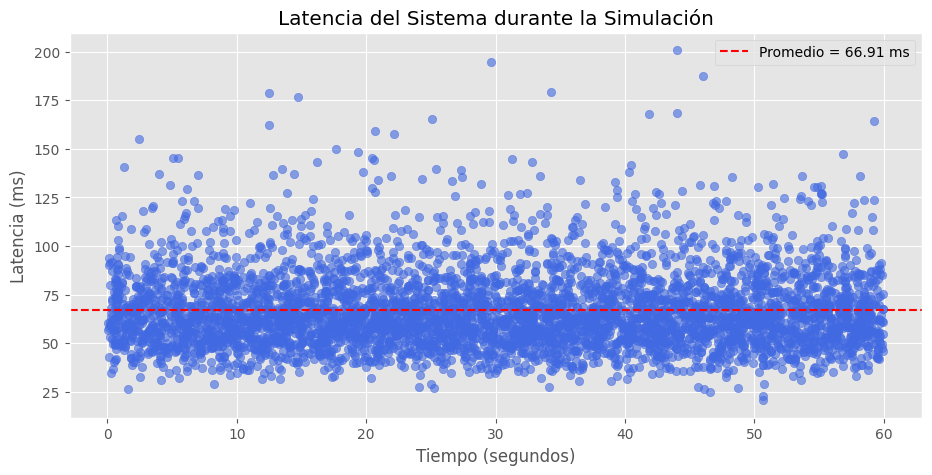

In [7]:
plt.figure(figsize=(11,5))

plt.scatter(
    sistema_red.marcas_tiempo,
    [t*1000 for t in sistema_red.tiempos_respuesta_total],
    alpha=0.6,
    color="royalblue"
)

plt.axhline(
    y=latencia_media_ms,
    color="red",
    linestyle="--",
    label=f"Promedio = {latencia_media_ms:.2f} ms"
)

plt.title("Latencia del Sistema durante la Simulación")

plt.xlabel("Tiempo (segundos)")

plt.ylabel("Latencia (ms)")

plt.legend()

plt.grid(True)

plt.show()